In [1]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_openai.chat_models import ChatOpenAI
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage

In [2]:
load_dotenv()

True

In [3]:
# tool
def multiply(a: int, b: int) -> int:
    """
    Multiply a and b

    Args:
        a: first int
        b: second int
    """
    return a*b

In [4]:
# defining an llm and providing it with a tool
llm = ChatOpenAI(model="gpt-4o-mini").bind_tools([multiply])

In [5]:
# node
def node_1(state: MessagesState):
    return {"messages": llm.invoke(state["messages"])}

In the previous implementation in the chain.ipynb notebook, we are only calling the tool but not actually executing it, that's why we get empty output. If we want to actually execute the tool we need to make a seperate ToolNode.

In [6]:
from langgraph.prebuilt import ToolNode, tools_condition

In [8]:
builder = StateGraph(MessagesState)

builder.add_node("node_1", node_1)
builder.add_node("tools", ToolNode([multiply]))
builder.add_edge(START, "node_1")
builder.add_conditional_edges("node_1", tools_condition)
builder.add_edge("tools", END)

graph = builder.compile()

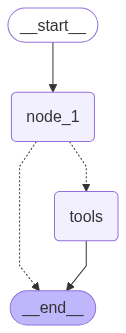

In [9]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [14]:
from langchain_core.messages import HumanMessage
messages = [HumanMessage(content="Hello, what is 2 multiplied by 2?")]
messages = graph.invoke({"messages": messages})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello, what is 2 multiplied by 2?
================================== Ai Message ==================================
Tool Calls:
  multiply (call_WjQpzCMN9qqYK921mwilxZUT)
 Call ID: call_WjQpzCMN9qqYK921mwilxZUT
  Args:
    a: 2
    b: 2
================================= Tool Message =================================
Name: multiply

4
